# La definición de derivada  

# los temas son:   

* hallar la derivada de $f(x)= |x|$ en $x$  
* hallar la derivada de 

$$
f(x)= \frac{1-x}{2+x} \quad \text{en} \quad x
$$ 

* demostrar la derivada de 1/g(X) ; g(x)≠0  

Y finalmente la duda de mis compañeros profe es entender la derivada pero desde la noción de limite

# Ejercicio 1: La derivada de la función valor absoluto  

Esta presentación didáctica aborda la derivación de la función valor absoluto, $f(x) = |x|$, explorando por qué es diferenciable en casi todo su dominio y qué sucede exactamente en el origen.





## 1. Definición de la Función
Para deducir la derivada, primero debemos expresar a $f(x) = |x|$ como una función definida a trozos:

$$f(x) = \begin{cases} x & \text{si } x \geq 0 \\ -x & \text{si } x < 0 \end{cases}$$



---



## 2. Deducción Analítica
Calculamos la derivada $f'(x)$ utilizando la definición de límite para los dos intervalos abiertos:



### Caso 1: Para $x > 0$
Si $x$ es positivo, $f(x) = x$. Por tanto:
$$f'(x) = \frac{d}{dx}(x) = 1$$



### Caso 2: Para $x < 0$
Si $x$ es negativo, $f(x) = -x$. Por tanto:
$$f'(x) = \frac{d}{dx}(-x) = -1$$



### Caso 3: El punto crítico $x = 0$
En el origen, evaluamos los límites laterales de la definición de derivada:
* **Límite por la derecha:** $\lim_{h \to 0^+} \frac{|0+h| - |0|}{h} = \lim_{h \to 0^+} \frac{h}{h} = 1$
* **Límite por la izquierda:** $\lim_{h \to 0^-} \frac{|0+h| - |0|}{h} = \lim_{h \to 0^-} \frac{-h}{h} = -1$

Como los límites laterales son diferentes ($1 \neq -1$), concluimos que **la función no es derivable en $x = 0$**.

---



## 3. Implementación en Python
A continuación, presentamos el código para visualizar la función, su pendiente (derivada) y una tabla de valores utilizando `pandas`, `matplotlib` y `seaborn`.


Muestra de valores calculados:
        x     f(x)  f'(x)
-5.000000 5.000000   -1.0
-3.997996 3.997996   -1.0
-2.995992 2.995992   -1.0
-1.993988 1.993988   -1.0
-0.991984 0.991984   -1.0
 0.010020 0.010020    1.0
 1.012024 1.012024    1.0
 2.014028 2.014028    1.0
 3.016032 3.016032    1.0
 4.018036 4.018036    1.0


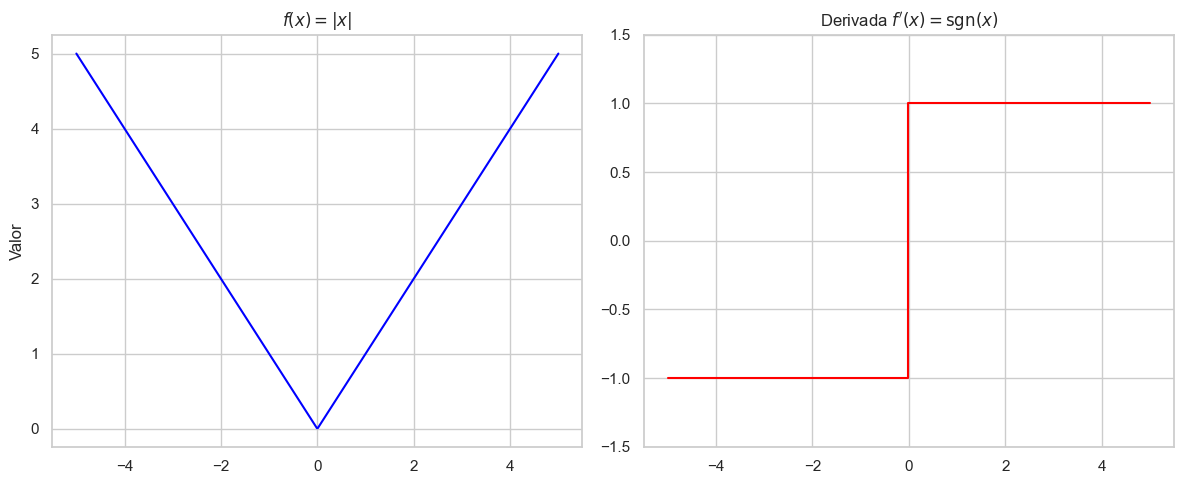

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# Configuración de estilo
sns.set_theme(style="whitegrid")

def generar_datos():
    x = np.linspace(-5, 5, 500)
    y = np.abs(x)
    # Derivada: 1 si x>0, -1 si x<0, NaN en 0
    y_prime = np.sign(x)
    return x, y, y_prime

x, y, y_prime = generar_datos()

# Visualización con Pandas
df = pd.DataFrame({'x': x, 'f(x)': y, "f'(x)": y_prime}).iloc[::50]
print("Muestra de valores calculados:")
print(df.to_string(index=False))

# Gráfico Estático con Matplotlib y Seaborn
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de f(x)
sns.lineplot(x=x, y=y, ax=ax[0], color='blue')
ax[0].set_title(r'$f(x) = |x|$')
ax[0].set_ylabel('Valor')

# Gráfico de f'(x)
sns.lineplot(x=x, y=y_prime, ax=ax[1], color='red', drawstyle='steps-pre')
ax[1].set_title(r"Derivada $f'(x) = \text{sgn}(x)$")
ax[1].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\derivada_de_valor_absoluto.png")
plt.show()


In [ ]:

# Visualización Interactiva con ipywidgets
def plot_interactivo(punto_x):
    plt.figure(figsize=(7, 4))
    plt.plot(x, y, label='f(x) = |x|')
    plt.scatter(punto_x, np.abs(punto_x), color='green', zorder=5)
    
    # Dibujar recta tangente (si existe)
    h = 0.5
    if punto_x != 0:
        m = np.sign(punto_x)
        x_tan = np.linspace(punto_x - h, punto_x + h, 10)
        y_tan = m * (x_tan - punto_x) + np.abs(punto_x)
        plt.plot(x_tan, y_tan, '--', color='orange', label=f'Pendiente: {m}')
    else:
        plt.text(0.5, 0.5, "No derivable en x=0", color='red', fontweight='bold')
    
    plt.axvline(0, color='black', lw=1)
    plt.axhline(0, color='black', lw=1)
    plt.title(f"Análisis de la pendiente en x = {punto_x}")
    plt.legend()
    plt.show()

widgets.interact(plot_interactivo, punto_x=widgets.FloatSlider(value=1.0, min=-4.0, max=4.0, step=0.1))


```

---

## 4. Conclusión
La derivada de la función valor absoluto se puede resumir mediante la función signo:

$$f'(x) = \frac{x}{|x|} = \text{sgn}(x) \quad \text{para } x \neq 0$$

* Si **$x > 0$**, la pendiente es constante e igual a $1$.
* Si **$x < 0$**, la pendiente es constante e igual a $-1$.
* En **$x = 0$**, existe un "punto anguloso" o cúspide, lo que impide la existencia de una única recta tangente.